In [17]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


检测到已有数据文件，跳过轨迹分析: combined_alhx_0.txt
----------------------------------------
合并统计结果:
平均邻居数: 13.13 ± 4.08
邻居数范围: 从 0 到 31
----------------------------------------
使用已有数据绘图，不重写数据文件: combined_alhx_0.txt
邻居数分布图已保存至: combined_alhx_0.png


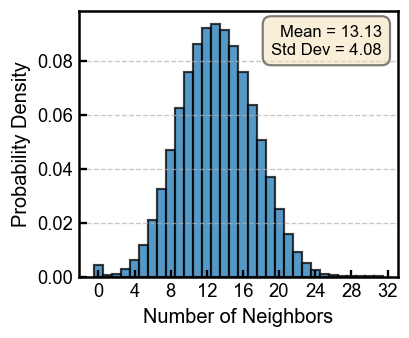

In [18]:
# -----------------------------------------------------------------------------
# analyze_combined_topology.py (CORRECTED VERSION)
#
# 功能:
# **正确地合并分析多个MD轨迹**。脚本会循环遍历每个轨迹文件，
# 对每个文件独立应用帧范围切片，然后将所有结果汇总进行统计。
# -----------------------------------------------------------------------------

import MDAnalysis as mda
import numpy as np
from MDAnalysis.lib.distances import distance_array
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import sys
import os

# ================= 用户参数设置 =================
# 只改这里：在 single_small / single_medium / double_short / double_medium / double_large 中切换
FIG_PRESET = "single_medium"

# --- 输入文件 ---
TOPOLOGY_FILE = '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr'

TRAJECTORY_FILES = [
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc'
]

# --- 输出文件 ---
OUTPUT_DATA_FILE = 'combined_alhx_0.txt'
OUTPUT_FIGURE_FILE = 'combined_alhx_0.png'
# True 时，如果 OUTPUT_DATA_FILE 已存在，就直接读取数据并绘图，跳过轨迹分析。
REUSE_EXISTING_DATA = True

# --- 轨迹切片参数 (将独立应用于每个轨迹文件) ---
START_FRAME = 10000
END_FRAME = -1 # 每个轨迹都分析到其各自的末尾
STRIDE = 1

# --- 分析参数 ---
CUTOFF_DISTANCE = 8.0
SELECTION_CRITERIA = 'protein and name BB'
RESIDUES_PER_CHAIN = 140
FORCE_SPLIT_BY_RESIDUE = True  # tpr 不能区分链时，按每 140 个残基强制切分蛋白链
# ==============================================


def get_protein_chains(u, residues_per_chain=140, force_split_by_residue=True):
    """
    返回蛋白链列表。

    如果 tpr 中 molecule 信息可靠，可以使用 split('molecule')；
    但当前体系的 tpr 不能区分不同蛋白链，因此默认按每 140 个残基切成一条链。
    """
    protein_all = u.select_atoms('protein')
    if protein_all.n_atoms == 0:
        print("  错误：在此轨迹中未找到 'protein'。")
        return []

    if not force_split_by_residue:
        try:
            chains = protein_all.split('molecule')
            if len(chains) > 1:
                print(f"  使用 split('molecule') 检测到 {len(chains)} 条链。")
                return chains
            print(f"  split('molecule') 只检测到 {len(chains)} 条链，改用按残基数切分。")
        except Exception as exc:
            print(f"  split('molecule') 失败，改用按残基数切分: {exc}")

    all_residues = protein_all.residues
    total_residues = len(all_residues)
    if total_residues % residues_per_chain != 0:
        raise ValueError(
            f"蛋白总残基数 ({total_residues}) 不能被每条链残基数 "
            f"({residues_per_chain}) 整除，请检查 protein 选择或 RESIDUES_PER_CHAIN。"
        )

    num_chains = total_residues // residues_per_chain
    chains = []
    for chain_idx in range(num_chains):
        start_idx = chain_idx * residues_per_chain
        end_idx = (chain_idx + 1) * residues_per_chain
        chains.append(all_residues[start_idx:end_idx].atoms)

    print(f"  按每 {residues_per_chain} 个残基一条链切分，得到 {num_chains} 条链。")
    return chains


def analyze_topology(
    u,
    start,
    end,
    stride,
    cutoff,
    selection,
    residues_per_chain=140,
    force_split_by_residue=True,
):
    """
    核心分析函数：对一个给定的Universe对象进行分析。
    """
    if end == -1:
        # u.trajectory 现在只包含一个轨迹，所以len()是正确的
        traj_slice = u.trajectory[start::stride]
        end_info = f"End ({len(u.trajectory)} frames total)"
    else:
        traj_slice = u.trajectory[start:end:stride]
        end_info = end

    n_analysis_frames = len(traj_slice)
    print(f"  分析范围: Frame {start} -> {end_info} (Stride: {stride})")
    print(f"  总计分析帧数: {n_analysis_frames}")

    protein_chains = get_protein_chains(
        u,
        residues_per_chain=residues_per_chain,
        force_split_by_residue=force_split_by_residue,
    )
    num_chains = len(protein_chains)
    if num_chains == 0:
        return np.array([])

    chain_selections = [chain.select_atoms(selection) for chain in protein_chains]
    empty_chain_ids = [idx + 1 for idx, chain_sel in enumerate(chain_selections) if chain_sel.n_atoms == 0]
    if empty_chain_ids:
        raise ValueError(f"以下链用选择语句 {selection!r} 没有选到原子: {empty_chain_ids}")

    all_neighbor_counts = []

    for i, ts in enumerate(traj_slice, start=1):
        adj_matrix = np.zeros((num_chains, num_chains), dtype=bool)
        for chain_idx_1 in range(num_chains):
            pos_1 = chain_selections[chain_idx_1].positions
            for chain_idx_2 in range(chain_idx_1 + 1, num_chains):
                pos_2 = chain_selections[chain_idx_2].positions
                if np.any(distance_array(pos_1, pos_2) < cutoff):
                    adj_matrix[chain_idx_1, chain_idx_2] = True
                    adj_matrix[chain_idx_2, chain_idx_1] = True

        neighbor_counts_this_frame = np.sum(adj_matrix, axis=1)
        all_neighbor_counts.extend(neighbor_counts_this_frame)
        sys.stdout.write(f"\r  处理进度: {i}/{n_analysis_frames} (Frame: {ts.frame})")
        sys.stdout.flush()

    print("\n  分析完成！")
    return np.array(all_neighbor_counts)


def get_combined_header(traj_files, neighbor_data):
    # (此函数无需修改)
    header_lines = [
        "Combined Neighbor Count Distribution Analysis",
        "Source Trajectories:"
    ]
    header_lines.extend([f"- {os.path.basename(f)}" for f in traj_files])
    header_lines.append("-" * 30)
    
    if neighbor_data.size > 0:
        mean_val = np.mean(neighbor_data)
        std_val = np.std(neighbor_data)
        header_lines.append(f"Statistics: Mean={mean_val:.3f}, StdDev={std_val:.3f}")
    
    header_lines.append("Data column: Neighbor_Counts")
    return "\n".join(header_lines)


def load_existing_results(output_data):
    """从已生成的数据文件读取邻居数；np.loadtxt 会自动跳过 # 开头的 header。"""
    data = np.loadtxt(output_data, dtype=int)
    data = np.atleast_1d(data)
    if data.size == 0:
        raise ValueError(f"已有数据文件为空: {output_data}")
    print(f"检测到已有数据文件，跳过轨迹分析: {output_data}")
    return data


def plot_and_save_results(neighbor_data, output_fig, output_data, traj_files, cutoff, save_data=True):
    if neighbor_data.size == 0:
        print("警告：没有收集到任何数据，无法进行统计和绘图。")
        return

    mean_neighbors = np.mean(neighbor_data)
    std_neighbors = np.std(neighbor_data)
    min_neighbors, max_neighbors = np.min(neighbor_data), np.max(neighbor_data)

    print("-" * 40)
    print("合并统计结果:")
    print(f"平均邻居数: {mean_neighbors:.2f} ± {std_neighbors:.2f}")
    print(f"邻居数范围: 从 {min_neighbors} 到 {max_neighbors}")
    print("-" * 40)

    if save_data:
        header_text = get_combined_header(traj_files, neighbor_data)
        np.savetxt(output_data, neighbor_data, fmt='%d', header=header_text)
        print(f"邻居数分布数据已保存至: {output_data}")
    else:
        print(f"使用已有数据绘图，不重写数据文件: {output_data}")

    mode_width, mode_height = FIG_PRESETS[FIG_PRESET]
    fig, ax = new_figure(mode=mode_width, height_mm=mode_height)
    bins = np.arange(min_neighbors, max_neighbors + 2) - 0.5
    ax.hist(neighbor_data, bins=bins, density=True, alpha=0.75,
            edgecolor='black', label='Combined Simulation Data')

    ax.set_xlabel('Number of Neighbors')
    ax.set_ylabel('Probability Density')
    #ax.set_title(f'Distribution of Protein Neighbors (Combined Trajectories, Cutoff = {cutoff} Å)', pad=5)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    stats_text = f'Mean = {mean_neighbors:.2f}\nStd Dev = {std_neighbors:.2f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            fontsize=mpl.rcParams['legend.fontsize'], verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
            
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.tight_layout()
    savefig_pub(fig, output_fig, tight=True)
    print(f"邻居数分布图已保存至: {output_fig}")
    plt.show()


def main():
    """
    主函数：循环加载每个轨迹，独立分析，最后合并结果。
    """
    if REUSE_EXISTING_DATA and os.path.exists(OUTPUT_DATA_FILE):
        combined_neighbor_data = load_existing_results(OUTPUT_DATA_FILE)
        plot_and_save_results(
            neighbor_data=combined_neighbor_data,
            output_fig=OUTPUT_FIGURE_FILE,
            output_data=OUTPUT_DATA_FILE,
            traj_files=TRAJECTORY_FILES,
            cutoff=CUTOFF_DISTANCE,
            save_data=False,
        )
        return

    all_results_list = []
    total_files = len(TRAJECTORY_FILES)

    print("="*60)
    print(f"开始对 {total_files} 个轨迹文件进行独立分析...")
    print("="*60)

    # **核心改动：循环遍历轨迹文件列表**
    for i, traj_file in enumerate(TRAJECTORY_FILES, start=1):
        print(f"\n--- 分析轨迹 {i}/{total_files}: {os.path.basename(traj_file)} ---")
        try:
            # **为每个轨迹创建一个独立的 Universe 对象**
            u = mda.Universe(TOPOLOGY_FILE, traj_file)
        except Exception as e:
            print(f"错误: 无法加载轨迹 {traj_file}。跳过此文件。\n{e}")
            continue

        # 对这个独立的轨迹执行分析
        results_this_traj = analyze_topology(
            u=u,
            start=START_FRAME,
            end=END_FRAME,
            stride=STRIDE,
            cutoff=CUTOFF_DISTANCE,
            selection=SELECTION_CRITERIA,
            residues_per_chain=RESIDUES_PER_CHAIN,
            force_split_by_residue=FORCE_SPLIT_BY_RESIDUE,
        )

        # 将本次分析的结果存入总列表
        if results_this_traj.size > 0:
            all_results_list.append(results_this_traj)

    if not all_results_list:
        print("\n错误：所有轨迹文件均未能成功分析，程序退出。")
        sys.exit(1)

    # **所有循环结束后，将结果合并成一个大的 numpy 数组**
    print("\n\n所有轨迹分析完成，正在合并结果...")
    combined_neighbor_data = np.concatenate(all_results_list)
    
    # 打印最终的统计信息，以供验证
    total_data_points = combined_neighbor_data.shape[0]
    total_proteins = len(get_protein_chains(
        mda.Universe(TOPOLOGY_FILE),
        residues_per_chain=RESIDUES_PER_CHAIN,
        force_split_by_residue=FORCE_SPLIT_BY_RESIDUE,
    ))
    expected_frames = (20000 - 10000) / STRIDE * len(TRAJECTORY_FILES) # 假设每个轨迹20000帧
    print(f"总数据点数: {total_data_points}")
    print(f"预期总分析帧数: {expected_frames:.0f} * {total_proteins} (蛋白数) = {expected_frames * total_proteins:.0f}")
    
    # 绘图和保存
    plot_and_save_results(
        neighbor_data=combined_neighbor_data,
        output_fig=OUTPUT_FIGURE_FILE,
        output_data=OUTPUT_DATA_FILE,
        traj_files=TRAJECTORY_FILES,
        cutoff=CUTOFF_DISTANCE
    )


if __name__ == '__main__':
    main()


检测到已有数据文件，跳过轨迹分析: combined_alhx_700.txt
----------------------------------------
合并统计结果:
平均邻居数: 10.43 ± 3.38
邻居数范围: 从 0 到 25
----------------------------------------
使用已有数据绘图，不重写数据文件: combined_alhx_700.txt
邻居数分布图已保存至: combined_alhx_700.png


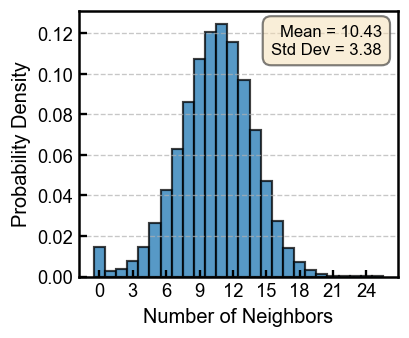

In [19]:
# -----------------------------------------------------------------------------
# analyze_combined_topology.py (CORRECTED VERSION)
#
# 功能:
# **正确地合并分析多个MD轨迹**。脚本会循环遍历每个轨迹文件，
# 对每个文件独立应用帧范围切片，然后将所有结果汇总进行统计。
# -----------------------------------------------------------------------------

import MDAnalysis as mda
import numpy as np
from MDAnalysis.lib.distances import distance_array
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import sys
import os

# ================= 用户参数设置 =================
# 只改这里：在 single_small / single_medium / double_short / double_medium / double_large 中切换
FIG_PRESET = "single_medium"

# --- 输入文件 ---
TOPOLOGY_FILE = '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr'

TRAJECTORY_FILES = [
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc',
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc'
]

# --- 输出文件 ---
OUTPUT_DATA_FILE = 'combined_alhx_700.txt'
OUTPUT_FIGURE_FILE = 'combined_alhx_700.png'
# True 时，如果 OUTPUT_DATA_FILE 已存在，就直接读取数据并绘图，跳过轨迹分析。
REUSE_EXISTING_DATA = True

# --- 轨迹切片参数 (将独立应用于每个轨迹文件) ---
START_FRAME = 10000
END_FRAME = -1 # 每个轨迹都分析到其各自的末尾
STRIDE = 1

# --- 分析参数 ---
CUTOFF_DISTANCE = 8.0
SELECTION_CRITERIA = 'protein and name BB'
RESIDUES_PER_CHAIN = 140
FORCE_SPLIT_BY_RESIDUE = True  # tpr 不能区分链时，按每 140 个残基强制切分蛋白链
# ==============================================


def get_protein_chains(u, residues_per_chain=140, force_split_by_residue=True):
    """
    返回蛋白链列表。

    如果 tpr 中 molecule 信息可靠，可以使用 split('molecule')；
    但当前体系的 tpr 不能区分不同蛋白链，因此默认按每 140 个残基切成一条链。
    """
    protein_all = u.select_atoms('protein')
    if protein_all.n_atoms == 0:
        print("  错误：在此轨迹中未找到 'protein'。")
        return []

    if not force_split_by_residue:
        try:
            chains = protein_all.split('molecule')
            if len(chains) > 1:
                print(f"  使用 split('molecule') 检测到 {len(chains)} 条链。")
                return chains
            print(f"  split('molecule') 只检测到 {len(chains)} 条链，改用按残基数切分。")
        except Exception as exc:
            print(f"  split('molecule') 失败，改用按残基数切分: {exc}")

    all_residues = protein_all.residues
    total_residues = len(all_residues)
    if total_residues % residues_per_chain != 0:
        raise ValueError(
            f"蛋白总残基数 ({total_residues}) 不能被每条链残基数 "
            f"({residues_per_chain}) 整除，请检查 protein 选择或 RESIDUES_PER_CHAIN。"
        )

    num_chains = total_residues // residues_per_chain
    chains = []
    for chain_idx in range(num_chains):
        start_idx = chain_idx * residues_per_chain
        end_idx = (chain_idx + 1) * residues_per_chain
        chains.append(all_residues[start_idx:end_idx].atoms)

    print(f"  按每 {residues_per_chain} 个残基一条链切分，得到 {num_chains} 条链。")
    return chains


def analyze_topology(
    u,
    start,
    end,
    stride,
    cutoff,
    selection,
    residues_per_chain=140,
    force_split_by_residue=True,
):
    """
    核心分析函数：对一个给定的Universe对象进行分析。
    """
    if end == -1:
        # u.trajectory 现在只包含一个轨迹，所以len()是正确的
        traj_slice = u.trajectory[start::stride]
        end_info = f"End ({len(u.trajectory)} frames total)"
    else:
        traj_slice = u.trajectory[start:end:stride]
        end_info = end

    n_analysis_frames = len(traj_slice)
    print(f"  分析范围: Frame {start} -> {end_info} (Stride: {stride})")
    print(f"  总计分析帧数: {n_analysis_frames}")

    protein_chains = get_protein_chains(
        u,
        residues_per_chain=residues_per_chain,
        force_split_by_residue=force_split_by_residue,
    )
    num_chains = len(protein_chains)
    if num_chains == 0:
        return np.array([])

    chain_selections = [chain.select_atoms(selection) for chain in protein_chains]
    empty_chain_ids = [idx + 1 for idx, chain_sel in enumerate(chain_selections) if chain_sel.n_atoms == 0]
    if empty_chain_ids:
        raise ValueError(f"以下链用选择语句 {selection!r} 没有选到原子: {empty_chain_ids}")

    all_neighbor_counts = []

    for i, ts in enumerate(traj_slice, start=1):
        adj_matrix = np.zeros((num_chains, num_chains), dtype=bool)
        for chain_idx_1 in range(num_chains):
            pos_1 = chain_selections[chain_idx_1].positions
            for chain_idx_2 in range(chain_idx_1 + 1, num_chains):
                pos_2 = chain_selections[chain_idx_2].positions
                if np.any(distance_array(pos_1, pos_2) < cutoff):
                    adj_matrix[chain_idx_1, chain_idx_2] = True
                    adj_matrix[chain_idx_2, chain_idx_1] = True

        neighbor_counts_this_frame = np.sum(adj_matrix, axis=1)
        all_neighbor_counts.extend(neighbor_counts_this_frame)
        sys.stdout.write(f"\r  处理进度: {i}/{n_analysis_frames} (Frame: {ts.frame})")
        sys.stdout.flush()

    print("\n  分析完成！")
    return np.array(all_neighbor_counts)


def get_combined_header(traj_files, neighbor_data):
    # (此函数无需修改)
    header_lines = [
        "Combined Neighbor Count Distribution Analysis",
        "Source Trajectories:"
    ]
    header_lines.extend([f"- {os.path.basename(f)}" for f in traj_files])
    header_lines.append("-" * 30)
    
    if neighbor_data.size > 0:
        mean_val = np.mean(neighbor_data)
        std_val = np.std(neighbor_data)
        header_lines.append(f"Statistics: Mean={mean_val:.3f}, StdDev={std_val:.3f}")
    
    header_lines.append("Data column: Neighbor_Counts")
    return "\n".join(header_lines)


def load_existing_results(output_data):
    """从已生成的数据文件读取邻居数；np.loadtxt 会自动跳过 # 开头的 header。"""
    data = np.loadtxt(output_data, dtype=int)
    data = np.atleast_1d(data)
    if data.size == 0:
        raise ValueError(f"已有数据文件为空: {output_data}")
    print(f"检测到已有数据文件，跳过轨迹分析: {output_data}")
    return data


def plot_and_save_results(neighbor_data, output_fig, output_data, traj_files, cutoff, save_data=True):
    if neighbor_data.size == 0:
        print("警告：没有收集到任何数据，无法进行统计和绘图。")
        return

    mean_neighbors = np.mean(neighbor_data)
    std_neighbors = np.std(neighbor_data)
    min_neighbors, max_neighbors = np.min(neighbor_data), np.max(neighbor_data)

    print("-" * 40)
    print("合并统计结果:")
    print(f"平均邻居数: {mean_neighbors:.2f} ± {std_neighbors:.2f}")
    print(f"邻居数范围: 从 {min_neighbors} 到 {max_neighbors}")
    print("-" * 40)

    if save_data:
        header_text = get_combined_header(traj_files, neighbor_data)
        np.savetxt(output_data, neighbor_data, fmt='%d', header=header_text)
        print(f"邻居数分布数据已保存至: {output_data}")
    else:
        print(f"使用已有数据绘图，不重写数据文件: {output_data}")

    mode_width, mode_height = FIG_PRESETS[FIG_PRESET]
    fig, ax = new_figure(mode=mode_width, height_mm=mode_height)
    bins = np.arange(min_neighbors, max_neighbors + 2) - 0.5
    ax.hist(neighbor_data, bins=bins, density=True, alpha=0.75,
            edgecolor='black', label='Combined Simulation Data')

    ax.set_xlabel('Number of Neighbors')
    ax.set_ylabel('Probability Density')
    #ax.set_title(f'Distribution of Protein Neighbors (Combined Trajectories, Cutoff = {cutoff} Å)', pad=5)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    stats_text = f'Mean = {mean_neighbors:.2f}\nStd Dev = {std_neighbors:.2f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            fontsize=mpl.rcParams['legend.fontsize'], verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
            
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.tight_layout()
    savefig_pub(fig, output_fig, tight=True)
    print(f"邻居数分布图已保存至: {output_fig}")
    plt.show()


def main():
    """
    主函数：循环加载每个轨迹，独立分析，最后合并结果。
    """
    if REUSE_EXISTING_DATA and os.path.exists(OUTPUT_DATA_FILE):
        combined_neighbor_data = load_existing_results(OUTPUT_DATA_FILE)
        plot_and_save_results(
            neighbor_data=combined_neighbor_data,
            output_fig=OUTPUT_FIGURE_FILE,
            output_data=OUTPUT_DATA_FILE,
            traj_files=TRAJECTORY_FILES,
            cutoff=CUTOFF_DISTANCE,
            save_data=False,
        )
        return

    all_results_list = []
    total_files = len(TRAJECTORY_FILES)

    print("="*60)
    print(f"开始对 {total_files} 个轨迹文件进行独立分析...")
    print("="*60)

    # **核心改动：循环遍历轨迹文件列表**
    for i, traj_file in enumerate(TRAJECTORY_FILES, start=1):
        print(f"\n--- 分析轨迹 {i}/{total_files}: {os.path.basename(traj_file)} ---")
        try:
            # **为每个轨迹创建一个独立的 Universe 对象**
            u = mda.Universe(TOPOLOGY_FILE, traj_file)
        except Exception as e:
            print(f"错误: 无法加载轨迹 {traj_file}。跳过此文件。\n{e}")
            continue

        # 对这个独立的轨迹执行分析
        results_this_traj = analyze_topology(
            u=u,
            start=START_FRAME,
            end=END_FRAME,
            stride=STRIDE,
            cutoff=CUTOFF_DISTANCE,
            selection=SELECTION_CRITERIA,
            residues_per_chain=RESIDUES_PER_CHAIN,
            force_split_by_residue=FORCE_SPLIT_BY_RESIDUE,
        )

        # 将本次分析的结果存入总列表
        if results_this_traj.size > 0:
            all_results_list.append(results_this_traj)

    if not all_results_list:
        print("\n错误：所有轨迹文件均未能成功分析，程序退出。")
        sys.exit(1)

    # **所有循环结束后，将结果合并成一个大的 numpy 数组**
    print("\n\n所有轨迹分析完成，正在合并结果...")
    combined_neighbor_data = np.concatenate(all_results_list)
    
    # 打印最终的统计信息，以供验证
    total_data_points = combined_neighbor_data.shape[0]
    total_proteins = len(get_protein_chains(
        mda.Universe(TOPOLOGY_FILE),
        residues_per_chain=RESIDUES_PER_CHAIN,
        force_split_by_residue=FORCE_SPLIT_BY_RESIDUE,
    ))
    expected_frames = (20000 - 10000) / STRIDE * len(TRAJECTORY_FILES) # 假设每个轨迹20000帧
    print(f"总数据点数: {total_data_points}")
    print(f"预期总分析帧数: {expected_frames:.0f} * {total_proteins} (蛋白数) = {expected_frames * total_proteins:.0f}")
    
    # 绘图和保存
    plot_and_save_results(
        neighbor_data=combined_neighbor_data,
        output_fig=OUTPUT_FIGURE_FILE,
        output_data=OUTPUT_DATA_FILE,
        traj_files=TRAJECTORY_FILES,
        cutoff=CUTOFF_DISTANCE
    )


if __name__ == '__main__':
    main()


Saved figure: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/inter-chain/combined_alhx_0_vs_700_nature_singlecol.png
Saved figure: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/inter-chain/combined_alhx_0_vs_700_nature_singlecol.pdf
alhx_0 mean ± std: 13.131 ± 4.081
alhx_700 mean ± std: 10.428 ± 3.381


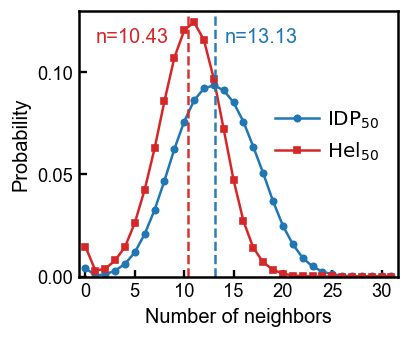

In [44]:
# Compare distributions from saved combined data files (alhx_0 and alhx_700)
# Shared publication style from the first cell + sparser ticks

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path

# 只改这里：在 single_small / single_medium / double_short / double_medium / double_large 中切换
FIG_PRESET = "single_medium"

# ---------- file paths ----------
base_dir = Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/inter-chain')
file_0 = base_dir / 'combined_alhx_0.txt'
file_700 = base_dir / 'combined_alhx_700.txt'

# ---------- load data ----------
# np.loadtxt automatically ignores lines starting with '#'.
data_0 = np.loadtxt(file_0, dtype=int)
data_700 = np.loadtxt(file_700, dtype=int)

# ---------- convert to probability distribution ----------
all_min = int(min(data_0.min(), data_700.min()))
all_max = int(max(data_0.max(), data_700.max()))
x = np.arange(all_min, all_max + 1)

count_0 = np.bincount(data_0 - all_min, minlength=len(x)).astype(float)
count_700 = np.bincount(data_700 - all_min, minlength=len(x)).astype(float)
prob_0 = count_0 / count_0.sum()
prob_700 = count_700 / count_700.sum()

mean_0 = float(np.mean(data_0))
mean_700 = float(np.mean(data_700))

# ---------- plot with shared publication style ----------
mode_width, mode_height = FIG_PRESETS[FIG_PRESET]
fig, ax = new_figure(mode=mode_width, height_mm=mode_height)

# Local style overrides: make marker smaller, match line width to axes,
# and unify text size with axis labels
MARKER_SIZE = 3.8
LINEWIDTH = mpl.rcParams.get('axes.linewidth', 1.5)
FS_LABEL = mpl.rcParams.get('axes.labelsize', 10)
FS_TICK = mpl.rcParams.get('xtick.labelsize', 9)
FS_LEGEND = FS_LABEL

ax.plot(
    x, prob_0,
    color='#1f77b4', marker='o', markersize=MARKER_SIZE, linewidth=LINEWIDTH,
    label=r"$\mathrm{IDP}_{50}$"
    )
ax.plot(
    x, prob_700,
    color='#d62728', marker='s', markersize=MARKER_SIZE, linewidth=LINEWIDTH,
    label=r"$\mathrm{Hel}_{50}$"
    )

# mean lines + labels
ymax = max(prob_0.max(), prob_700.max())
ax.axvline(mean_0, color='#1f77b4', linestyle='--', alpha=0.95, linewidth=LINEWIDTH)
ax.axvline(mean_700, color='#d62728', linestyle='--', alpha=0.95, linewidth=LINEWIDTH)
ax.text(mean_0 + 1, ymax * 0.98, f'n={mean_0:.2f}', color='#1f77b4',
        fontsize=FS_LABEL, rotation=0, va='top', ha='left')
ax.text(mean_700 - 2, ymax * 0.98, f'n={mean_700:.2f}', color='#d62728',
        fontsize=FS_LABEL, rotation=0, va='top', ha='right')

ax.set_xlabel('Number of neighbors', fontsize=FS_LABEL)
ax.set_ylabel('Probability', fontsize=FS_LABEL)

# make ticks less dense and larger
ax.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
ax.set_yticks([0.00, 0.05, 0.10])
ax.set_ylim(0.0, 0.13)
ax.tick_params(axis='both', which='major', labelsize=FS_TICK)

ax.legend(
    frameon=False,
    handlelength=2.2,
    fontsize=FS_LEGEND,
    loc='upper right',
    bbox_to_anchor=(1.0, 0.7)
)

ax.margins(x=0.02)
fig.tight_layout()

out_png = base_dir / 'combined_alhx_0_vs_700_nature_singlecol.png'
out_pdf = base_dir / 'combined_alhx_0_vs_700_nature_singlecol.pdf'
savefig_pub(fig, out_png, tight=True)
savefig_pub(fig, out_pdf, tight=True)
print(f'Saved figure: {out_png}')
print(f'Saved figure: {out_pdf}')
print(f'alhx_0 mean ± std: {np.mean(data_0):.3f} ± {np.std(data_0):.3f}')
print(f'alhx_700 mean ± std: {np.mean(data_700):.3f} ± {np.std(data_700):.3f}')

plt.show()
